In [26]:
import xarray as xr
import icechunk

from obstore.store import from_url
import zarr 
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from virtualizarr.registry import ObjectStoreRegistry
from distributed import Client

import tempfile

In [27]:
client = Client()
client

/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 63612 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:63612/status,
Dashboard: http://127.0.0.1:63612/status,Workers: 5
Total threads: 10,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:63613,Workers: 0
Dashboard: http://127.0.0.1:63612/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:63629,Total threads: 2
Dashboard: http://127.0.0.1:63632/status,Memory: 3.20 GiB
Nanny: tcp://127.0.0.1:63616,


In [28]:
urls = [
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_201501-201912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_202001-202412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_202501-202912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_203001-203412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_203501-203912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_204001-204412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_204501-204912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_205001-205412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_205501-205912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_206001-206412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_206501-206912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_207001-207412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_207501-207912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_208001-208412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_208501-208912.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_209001-209412.nc",
    "https://esgf-node.ornl.gov/thredds/fileServer/css03_data/CMIP6/ScenarioMIP/DKRZ/MPI-ESM1-2-HR/ssp126/r1i1p1f1/Amon/tas/gn/v20190710/tas_Amon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_210001-210012.nc",
]

bucket = "https://esgf-node.ornl.gov"
store = from_url(bucket)
registry = ObjectStoreRegistry({bucket: store})

parser = HDFParser()

In [29]:
# Alt. option for loading a single url
# manifest_store = parser(
#     url=urls[0],
#     registry=registry
# )
# loadable_ds = xr.open_zarr(
#     manifest_store,
#     consolidated=False,
#     zarr_format=3,
# )

In [30]:
vds = open_virtual_mfdataset(
    urls=urls,
    parser=parser,
    registry=registry,
    compat="override",
    coords="minimal",
    loadable_variables=[
        "lon",
        "lat",
        "time",
        "bnds",
        "time_bnds",
        "lat_bnds",
        "lon_bnds",
    ],
    parallel="dask",
)
vds

/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/zarr/codecs/num

<xarray.Dataset> Size: 296MB
Dimensions:    (time: 972, bnds: 2, lat: 192, lon: 384)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
    height     float64 8B ManifestArray<shape=(), dtype=float64, chunks=()>
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16kB 2015-01-01 ... 2101-01-01
    lat_bnds   (time, lat, bnds) float64 3MB -89.75 -88.82 ... 88.82 89.75
    lon_bnds   (time, lon, bnds) float64 6MB -0.4688 0.4688 ... 358.6 359.5
    tas        (time, lat, lon) float32 287MB ManifestArray<shape=(972, 192, ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by DKRZ is licensed und...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/981bf19d-e45d-478d-97a8-3214485079b6

In [31]:
url_prefix = "https://esgf-node.ornl.gov/"
config = icechunk.RepositoryConfig.default()

config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=url_prefix,
        store=icechunk.http_store(),
    ),
)

local_storage = icechunk.local_filesystem_storage("./cmip")
repo = icechunk.Repository.open_or_create(local_storage, config)
session = repo.writable_session("main")

vds.vz.to_icechunk(session.store)

snapshot_id = session.commit("cmip")
print(snapshot_id)

repo.save_config()

  2025-10-31T21:22:28.834159Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:80

62HV2GC1YHWX0HX3FVA0


In [32]:
repo = icechunk.Repository.open(
    storage=local_storage,
    config=config,
    authorize_virtual_chunk_access={
        url_prefix: None 
    }
)
session = repo.readonly_session('main')
rtds = xr.open_zarr(session.store)


/Users/juliusbusecke/Code/esgf-virtual-zarr-data-access/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


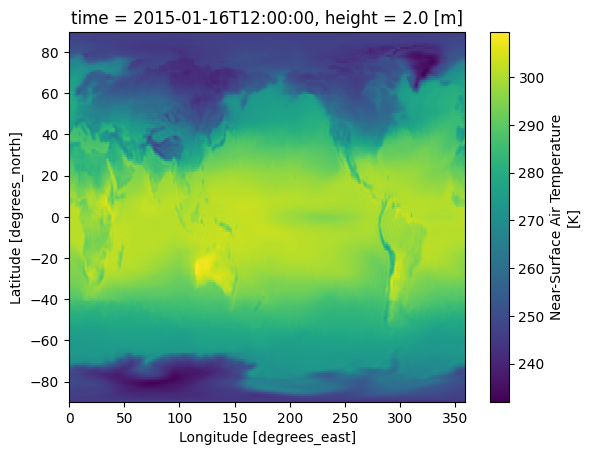

In [33]:
rtds.isel(time=0).tas.plot()

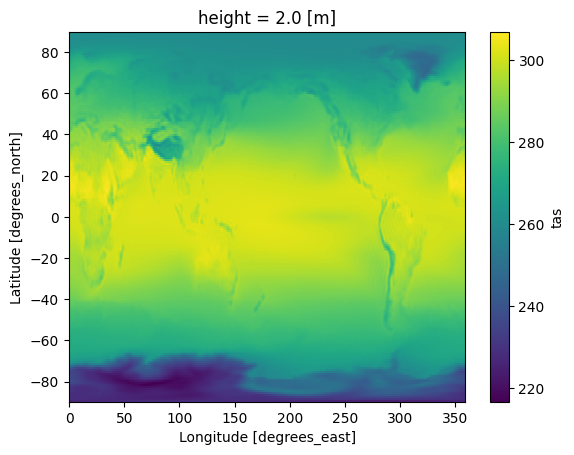

In [34]:
rtds.mean('time').tas.plot()

In [35]:
rtds.nbytes/1e6

295.64036

150kb for the store compared to 300MB for the original data.